MRI shape: (91, 109)
PET shape: (91, 109)


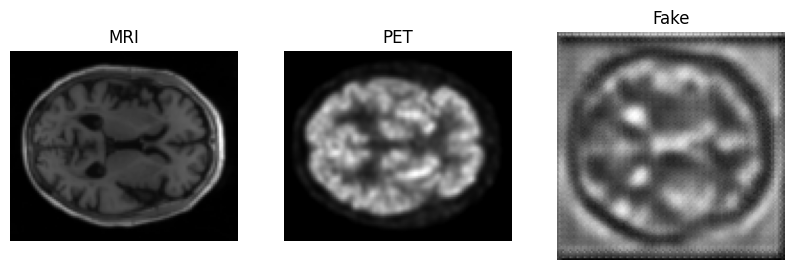

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import Yang_2025  as mymodel   #Yang_2025
import importlib
import torch.nn.functional as F
_=importlib.reload(mymodel)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load trained models
# -----------------------------
generator = mymodel.Generator().to(device)
discriminator = mymodel.Discriminator().to(device)
mainPath=r"C:\Users\fhabi\Desktop\PhD\GAN\SourceCodes\PhD_GAN\Result\weights"
generator_path=mainPath+f"\{mymodel.__name__}_best_generator.pth"
discriminator_path=mainPath+f"\{mymodel.__name__}_best_discriminator.pth"
generator.load_state_dict(torch.load(generator_path, map_location=device))
discriminator.load_state_dict(torch.load(discriminator_path, map_location=device))
generator.eval()
discriminator.eval()
import Helper_Functions
Helper_Functions.Plot_Example(generator, test_loader, device)
# -----------------------------
# Image paths
# -----------------------------
main=r"C:\Users\fhabi\Desktop\PhD\GAN\SourceCodes\PhD_GAN\Result\weights\TestData"
mri_path = main+r"\MRI\mri.nii"
pet_path = main+r"\PET\pet.nii"

# -------------------------
# load NIfTI
# -------------------------
mri_nii = nib.load(mri_path)
pet_nii = nib.load(pet_path)

mri = mri_nii.get_fdata()
pet = pet_nii.get_fdata()
mri_tensor = torch.from_numpy(mri).unsqueeze(0).unsqueeze(0).float().to(device)
mri_tensor = F.interpolate(
    mri_tensor,
    size=(128, 128),
    mode='bilinear',
    align_corners=False
)
fake=generator(mri_tensor)
fake_img = fake.detach().cpu().squeeze().numpy()
print("MRI shape:", mri.shape)
print("PET shape:", pet.shape)

# -------------------------
# handle 2D vs 3D safely
# -------------------------
if len(mri.shape) == 3:
    z = mri.shape[2] // 2
    mri_img = mri[:, :, z]
    pet_img = pet[:, :, z]
else:
    mri_img = mri
    pet_img = pet

# -------------------------
# normalize
# -------------------------
def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

mri_img = norm(mri_img)
pet_img = norm(pet_img)

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(mri_img, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pet_img, cmap="gray")
plt.title("PET")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(fake_img, cmap="gray")
plt.title("Fake")
plt.axis("off")
plt.show()